# Inläning av Torchcam och analys

In [60]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask
import json
import torch

Här hämtar vi som vanligt in de bibliotek som vi behöver för att fullfölja uppgiften

In [61]:
weights = get_model_weights ('resnet18').DEFAULT
model = get_model('resnet18', weights=weights).eval()

preprocess  = weights.transforms()
img = decode_image ("C:/Users/matti/Downloads/Atlas_moth.webp")

I sektionen över så väljer vi att anväda de redan angivna parrametrarna som ResNet18 redan har som standard

In [62]:
input_tensor= preprocess (img)

with LayerCAM(model) as cam_extractor:
    out = model (input_tensor.unsqueeze(0))
    activation_map = cam_extractor (out.squeeze(0).argmax().item(), out)


<function matplotlib.pyplot.show(close=None, block=None)>

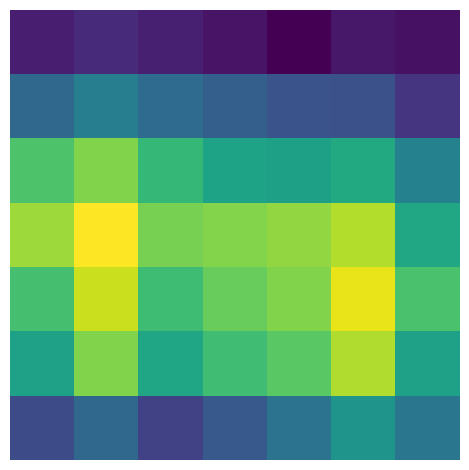

In [63]:
plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis('off')
plt.tight_layout()
plt.show


Vi kan se att programmet fokuserar på två punkter, en på nästan vardera del av bilden. Men vad är det som detta ger oss? Ett enkelt sett att se detta är om vi börjar med att lägga den ena bilden ovanpå den andra.

<function matplotlib.pyplot.show(close=None, block=None)>

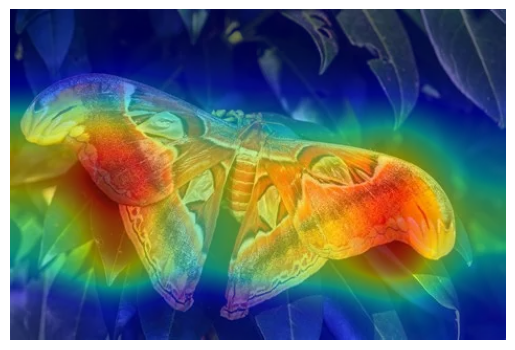

In [64]:
result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'),alpha=0.5)
plt.imshow(result)
plt.axis('off')
plt.tight_layout
plt.show

Här börjar vi att lägga vår analysbild ovanpå vår orginalbild. vilket get oss en klarare bid av vad vi tittar på men även vad det är som programmet fokuserar på. Vi kan se i den bild vi har att programmet fokuserar på malens vingar. Vilket i de flesta fall när det kommer till malar och fjärilar är ett bra ställe att titta på.


In [65]:
def predict_class (output_tensor: torch.Tensor, class_index_path: str) -> dict:
    with open (class_index_path, 'r') as f:
        class_index = json.load(f)
    
    probs = output_tensor.squeeze()
    if probs.ndim!=1 or probs.shape[0] !=1000:
        raise ValueError(f'The shape isnt of a value of 1000, instead its {tuple(output_tensor.shape)}')
    
    top_idx = int(probs.argmax())
    synset_id, class_name = class_index[str(top_idx)]
    return{'class_index' : top_idx,
           'class_id': synset_id,
           'class_name': class_name,
           'confidence': float(probs[top_idx]),
           }

In [68]:
model.eval()
batch = preprocess (img).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)
prediction.detach()

tensor([3.6497e-04, 1.6077e-03, 1.9653e-06, 1.2755e-05, 2.3074e-06, 7.4557e-06,
        4.3056e-07, 2.4914e-04, 1.8306e-05, 3.7341e-06, 9.3908e-06, 4.9635e-06,
        1.3790e-04, 8.3569e-07, 1.8425e-05, 1.0171e-04, 5.1969e-06, 6.8481e-06,
        1.5280e-06, 1.3944e-06, 9.0476e-08, 1.0885e-05, 3.5114e-07, 9.4583e-05,
        3.7480e-05, 1.1442e-04, 7.7361e-04, 2.4042e-04, 3.8234e-06, 2.3579e-04,
        9.5172e-05, 1.8298e-03, 7.8348e-03, 3.6046e-03, 3.0814e-04, 1.9702e-03,
        2.1818e-04, 1.1099e-03, 1.3570e-04, 1.8595e-03, 8.5068e-05, 3.5844e-05,
        1.5206e-03, 5.8143e-03, 6.3214e-06, 2.1410e-05, 5.9578e-05, 2.0882e-01,
        3.9936e-05, 2.6109e-04, 4.5437e-05, 6.1034e-02, 6.9318e-05, 8.5970e-06,
        4.2681e-05, 1.3726e-05, 3.6541e-06, 5.5035e-06, 6.4955e-06, 1.3420e-04,
        2.8679e-04, 3.1644e-04, 1.1358e-04, 2.1985e-05, 9.3681e-06, 1.3474e-05,
        5.8717e-05, 6.7995e-06, 2.0246e-05, 3.2319e-05, 6.4790e-05, 1.2470e-04,
        1.6881e-05, 1.5107e-04, 3.3816e-

In [72]:
predict_class (prediction,"C:/Users/matti/Downloads/imagenet_class_index.json")

C:\Users\matti\AppData\Local\Temp\ipykernel_2800\1479621322.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  'confidence': float(probs[top_idx]),


{'class_index': 47,
 'class_id': 'n01694178',
 'class_name': 'African_chameleon',
 'confidence': 0.20882228016853333}